In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from aif360.datasets import BinaryLabelDataset
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

c:\Users\umert\anaconda3\envs\den_env\Lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
c:\Users\umert\anaconda3\envs\den_env\Lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg =

In [3]:
def calculate_disparate_impact(protected_group,unprotected_group):
    
    # Compute the selection rate for groups
    protected_group_rate = sum(protected_group) / len(protected_group)
    unprotected_group_rate = sum(unprotected_group) / len(unprotected_group)

    if protected_group_rate == 0:
        raise ValueError("Privileged group selection rate is zero; disparate impact is undefined.")
    
    # Compute disparate impact
    disparate_impact = unprotected_group_rate / protected_group_rate
    return disparate_impact

In [4]:
protected_outcomes = [1, 0, 1, 1, 1, 0]  
unprotected_outcomes = [0, 0, 1, 0, 1, 0]  


di = calculate_disparate_impact(protected_outcomes, unprotected_outcomes)
print(f"Disparate Impact: {di}")


if di < 0.8:
    print("Potential unfairness detected (DI < 0.8).")
elif di > 1.25:
    print("Potential reverse bias detected (DI > 1.25).")
else:
    print("Fairness is within acceptable range.")

Disparate Impact: 0.5
Potential unfairness detected (DI < 0.8).


In [5]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "gender",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# Load with column names
df = pd.read_csv('adult.data', names=columns, header=None, skipinitialspace=True)



In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:

df = df.dropna()


data = df[["gender", "income"]]


data.loc[:, "income"] = data["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Separate privileged (Male) and unprivileged (Female) groups

privileged = data[data["gender"] == "Male"]["income"]
unprivileged = data[data["gender"] == "Female"]["income"]


privileged_rate = privileged.mean()
unprivileged_rate = unprivileged.mean()

# Calculate disparate impact
disparate_impact = unprivileged_rate / privileged_rate
print(f"Privileged Group Selection Rate (Male): {privileged_rate:.2f}")
print(f"Unprivileged Group Selection Rate (Female): {unprivileged_rate:.2f}")
print(f"Disparate Impact: {disparate_impact:.2f}")

# Interpret results
if disparate_impact < 0.8:
    print("Potential unfairness detected (DI < 0.8).")
elif disparate_impact > 1.25:
    print("Potential reverse bias detected (DI > 1.25).")
else:
    print("Fairness is within acceptable range.")


Privileged Group Selection Rate (Male): 0.31
Unprivileged Group Selection Rate (Female): 0.11
Disparate Impact: 0.36
Potential unfairness detected (DI < 0.8).


In [8]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


In [9]:
unique_races = df["race"].unique()

print("Unique values in 'race':", unique_races)

Unique values in 'race': ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']


In [10]:
data1 = df[["race", "income"]]

In [11]:
privileged_group = data1[data1["race"] == "White"]
unprivileged_group = data1[data1["race"] == "Black"]


P_Y1_S1 = (privileged_group["income"] == ">50K").mean()  
P_Y1_S0 = (unprivileged_group["income"] == ">50K").mean()  

# Calculate Disparate Impact (DI)
disparate_impact_race = P_Y1_S0 / P_Y1_S1

# Print the result
print(f"Disparate Impact for race: {disparate_impact_race}")

Disparate Impact for race: 0.484169749550993


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

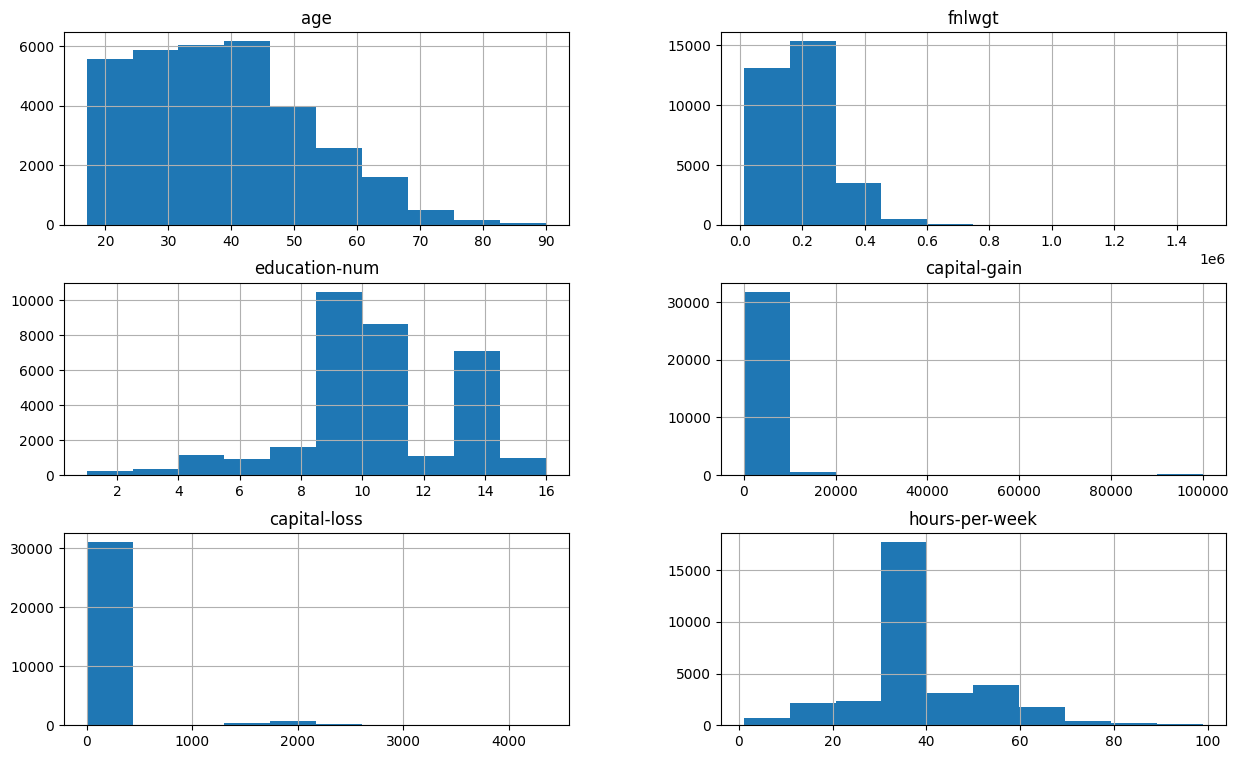

In [12]:
df.hist(figsize=(15,9))

In [13]:
data_after_duplicates=df.drop_duplicates()

In [14]:
data_after_duplicates.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
data_cleaned= data_after_duplicates.dropna()

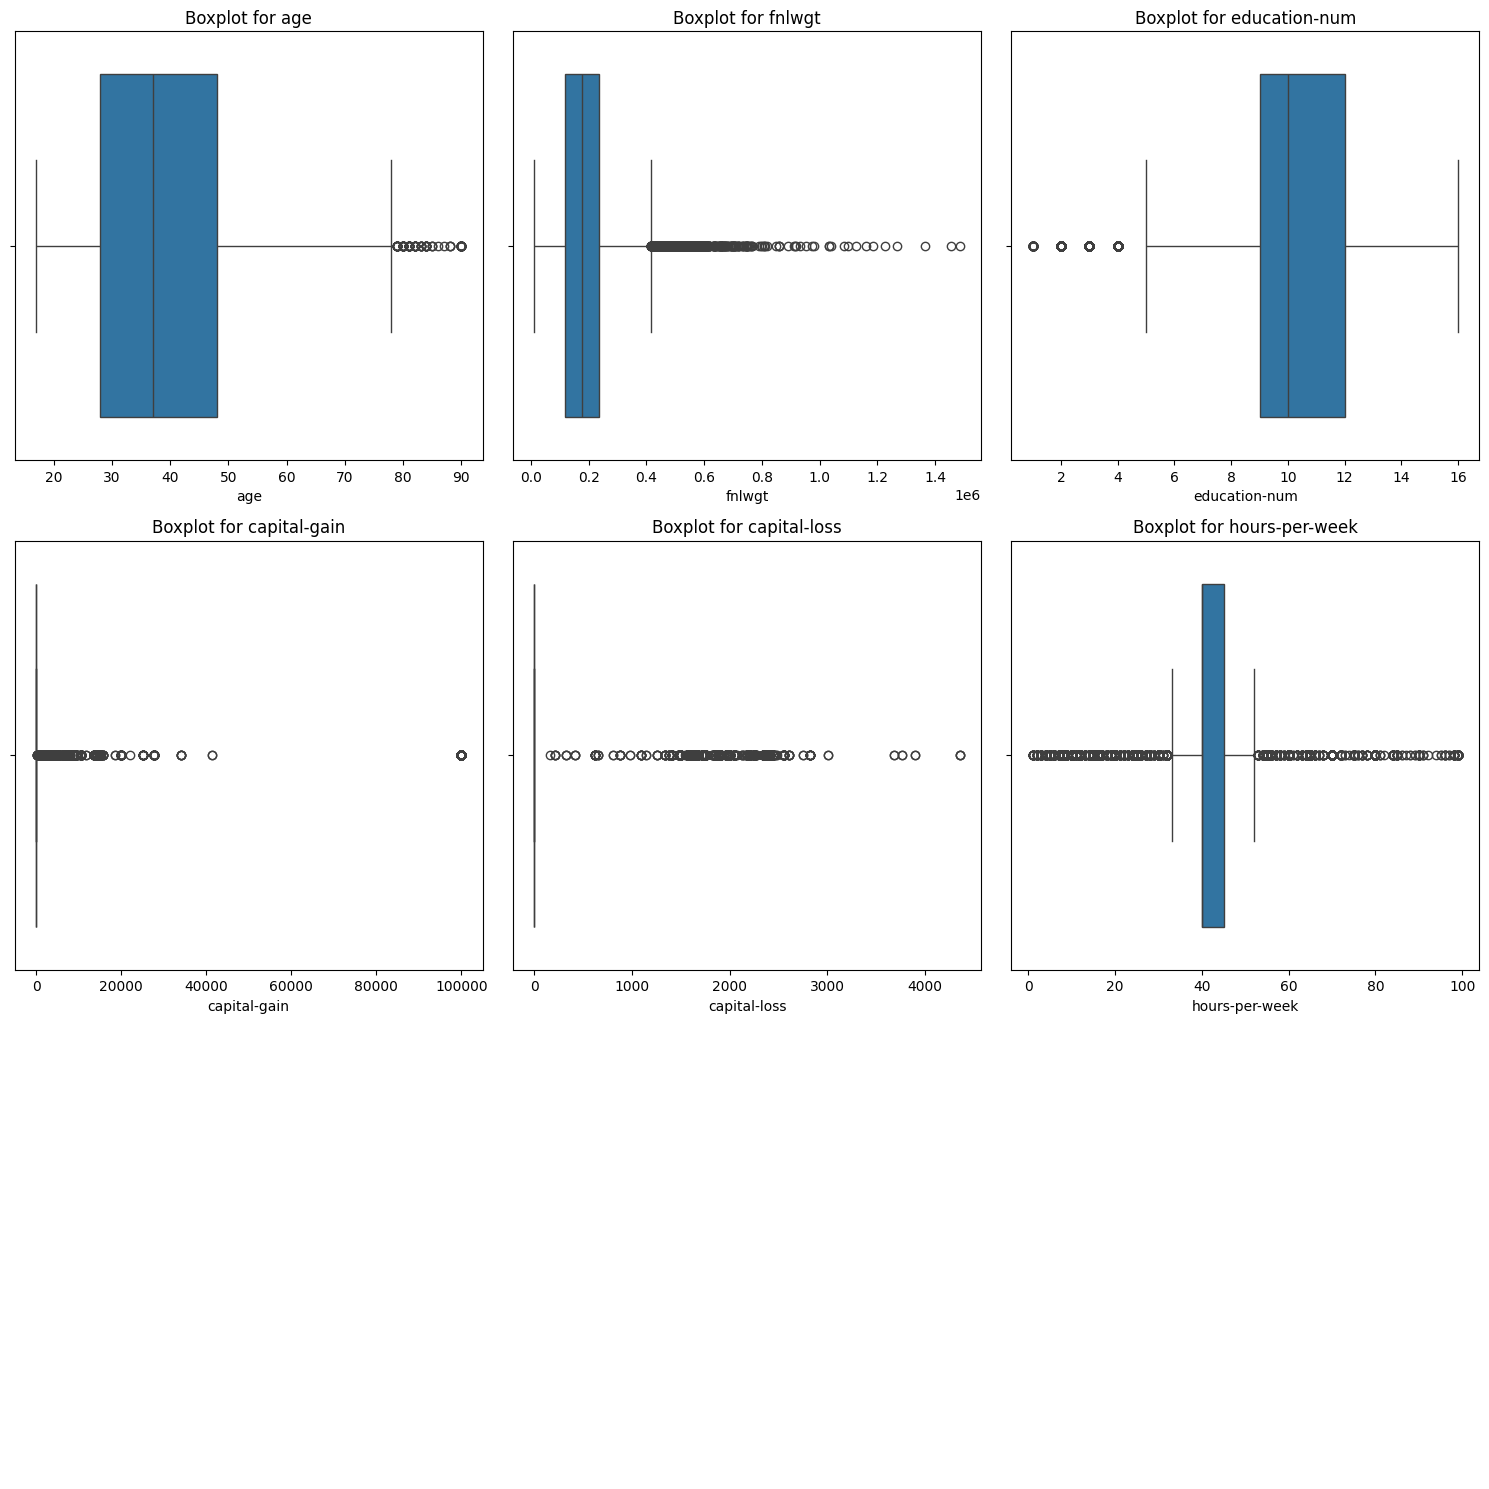

In [16]:
numerical_columns = data_cleaned.select_dtypes(include=['float64', 'int64']).columns


n_features = len(numerical_columns)
n_cols = 3  
n_rows = 3  


fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))


axes = axes.flatten()

# Generate boxplots for each numerical column
for i, col in enumerate(numerical_columns):
    sns.boxplot(x=data_cleaned[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [17]:
unique_capital_gain = data_cleaned["capital-gain"].unique()

print("Unique values in capital_gain:", len(unique_capital_gain))

Unique values in capital_gain: 119


In [18]:
def remove_outliers_iqr(df):
    for column in df.select_dtypes(include='number').columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Keep only values within the bounds
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers
df_no_outliers = remove_outliers_iqr(data_cleaned)




In [19]:
import numpy as np

In [20]:
correlation_matrix= df_no_outliers.select_dtypes(include=[np.number]).corr()

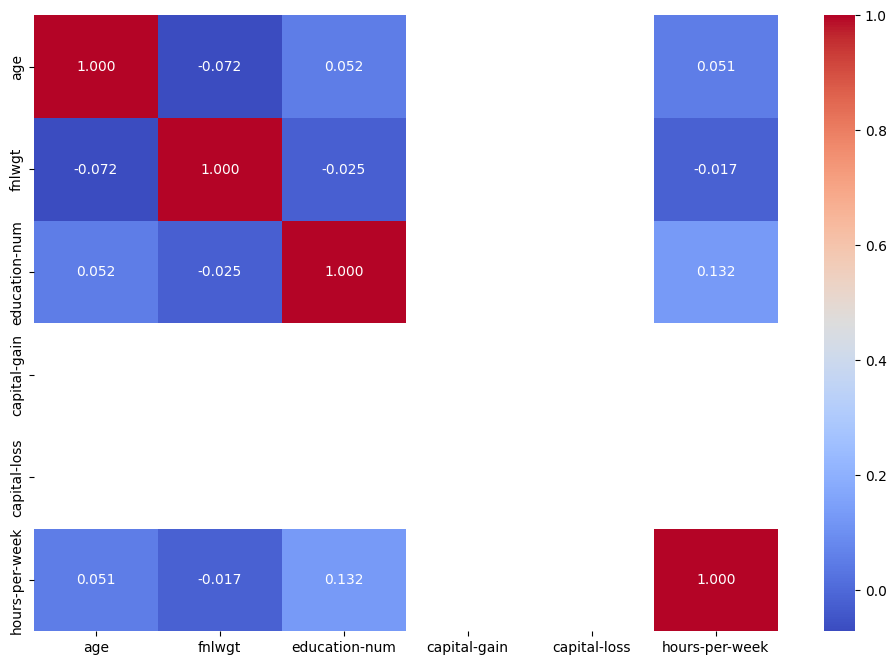

In [21]:
plt.figure(figsize=(12,8))
corr_matrix= sns.heatmap(correlation_matrix , annot=True , cmap= 'coolwarm' , fmt='.3f' )

In [22]:
df_new=df_no_outliers.drop("capital-gain" , axis=1)

In [23]:
df_new=df_new.drop("capital-loss", axis=1)

In [24]:

encoder = OneHotEncoder(sparse_output=False, drop='first')  

encoded_array = encoder.fit_transform(df_new[['income']])

encoded_columns = encoder.get_feature_names_out(['income'])

encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)


df_encoded_income = pd.concat([df_new.drop(columns=['income']), encoded_df], axis=1)



In [25]:
df1=df_encoded_income.copy()


In [26]:
unique_workclass = df1["workclass"].unique()

print("Unique values in workclass:", len(unique_workclass))

Unique values in workclass: 10


In [27]:
unique_fnlwgt = df1["fnlwgt"].unique()

print("Unique values in fnlwgt:", len(unique_fnlwgt))

Unique values in fnlwgt: 14001


In [28]:
df1=df1.drop("fnlwgt", axis=1)


In [29]:
unique_education= df1["education"].unique()

print("Unique values in education:", len(unique_education))

Unique values in education: 13


In [30]:
unique_marital8status= df1["marital-status"].unique()

print("Unique values in marital-status:", len(unique_marital8status))

Unique values in marital-status: 8


In [31]:
unique_occupation= df1["occupation"].unique()

print("Unique values in occupation:", len(unique_occupation))

Unique values in occupation: 16


In [32]:
unique_relationship= df1["relationship"].unique()

print("Unique values in relationship:", len(unique_relationship))

Unique values in relationship: 7


In [33]:
unique_relationship1= df1["native-country"].unique()

print("Unique values in native-country:", len(unique_relationship1))

Unique values in native-country: 42


In [34]:
df2=df1.copy()

In [35]:
df2.loc[:, "native-country"] = df2["native-country"].apply(lambda x: 1 if x == "United-States" else 0)

In [36]:
df2= df2.drop('marital-status' , axis=1)

In [37]:
df2.drop('education', axis=1)

,age,workclass,education-num,occupation,relationship,race,gender,hours-per-week,native-country,income_>50K
2,38.0,Private,9.0,Handlers-cleaners,Not-in-family,White,Male,40.0,1,0.0
3,53.0,Private,7.0,Handlers-cleaners,Husband,Black,Male,40.0,1,0.0
4,28.0,Private,13.0,Prof-specialty,Wife,Black,Female,40.0,0,1.0
5,37.0,Private,14.0,Exec-managerial,Wife,White,Female,40.0,1,1.0
7,52.0,Self-emp-not-inc,9.0,Exec-managerial,Husband,White,Male,45.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...
18984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
18987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
18988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
18989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0


In [38]:



categorical_cols = df2.select_dtypes(include=['object', 'category']).columns


columns_to_encode = [col for col in categorical_cols if col]

df_encoded = pd.get_dummies(df2, columns=columns_to_encode, drop_first=True)

In [39]:
df_cleaned = df_encoded.dropna()


In [40]:
unique_education1= df_cleaned["gender_Male"].unique()

print("Unique values in education:", unique_education1)

Unique values in education: [ True False]


In [41]:
privileged_groups = df_cleaned['gender_Male']==1 
unprivileged_groups = df_cleaned['gender_Male']==0


# Splitting
X = df_cleaned.drop(columns=['income_>50K'])
y = df_cleaned['income_>50K']




In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print ( "X_test data:", len(X_test))
print("X_train data:", len(X_train))
print("y_train data:" ,len(y_train))
print("y_test data:" ,len(y_test))

X_test data: 2224
X_train data: 8895
y_train data: 8895
y_test data: 2224


In [43]:

# Train a Random Forest model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)
print(len(y_pred))

2224


In [44]:
y_train_pred = clf.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy}")

Training Accuracy: 0.963575042158516


In [45]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy:",{accuracy})

Test Accuracy: {0.7324640287769785}


In [46]:
tdf=pd.concat([X_test, y_test], axis=1)

In [47]:
dataset1 = BinaryLabelDataset(favorable_label=1, 
                            unfavorable_label=0,
                            df=tdf,
                            label_names=['income_>50K'], protected_attribute_names=['gender_Male'])

In [48]:
feature_names = dataset1.feature_names

features_df = pd.DataFrame(dataset1.features, columns=feature_names)

**Fitting the model on features of binary dataset**

In [49]:
y_pred1 = clf.predict(features_df)

print(f"Predictions (y_pred1) length: {len(y_pred1)}")

Predictions (y_pred1) length: 2224


**Groups to Inspect**

In [50]:
unprivileged_groups = [{'gender_Male': False}]  
privileged_groups = [{'gender_Male': True}] 

In [51]:
sensitive_features= X_test['gender_Male']

In [52]:
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred: {len(y_pred1)}")
print(f"Length of sensitive_features: {len(sensitive_features)}")

Length of y_test: 2224
Length of y_pred: 2224
Length of sensitive_features: 2224


**Metrics of FairLearn package**

In [53]:

dp_diff = demographic_parity_difference(y_test, y_pred1, sensitive_features=sensitive_features)
eo_diff = equalized_odds_difference(y_test, y_pred1, sensitive_features=sensitive_features)

print(f'Demographic Parity Difference: {dp_diff}')
print(f'Equalized Odds Difference: {eo_diff}')


Demographic Parity Difference: 0.029246912061526395
Equalized Odds Difference: 0.034591194968553465


**Fairness metrics of aif360**


In [54]:
binary_dataset = BinaryLabelDataset(
    favorable_label=1, 
    unfavorable_label=0,
    df=tdf,  
    label_names=['income_>50K'],  
    protected_attribute_names=['gender_Male']  
)

In [55]:
dataset_to_classify = BinaryLabelDataset(favorable_label=1, 
                            unfavorable_label=0,
                            df=tdf,
                            label_names=['income_>50K'], protected_attribute_names=['gender_Male'])

In [56]:
df_test= pd.concat([X_test , y_test], axis=1)

**Fairness Metrics in aif360**

In [57]:
dataset = BinaryLabelDataset(
    df=df_test,
    label_names=['income_>50K'],  
    protected_attribute_names=['gender_Male'],  
    favorable_label=1,  
    unfavorable_label=0 
)


dataset_pred = dataset.copy()
dataset_pred.labels = y_pred1

In [58]:
metric = BinaryLabelDatasetMetric(dataset_pred, privileged_groups=[{'gender_Male': 1}], unprivileged_groups=[{'gender_Male': 0}])

In [59]:
di = metric.disparate_impact()
print(f"Disparate Impact: {di}")

Disparate Impact: 0.7351727779794713


In [60]:
statistical_parity = metric.statistical_parity_difference()
print(f"Statistical Parity Difference: {statistical_parity}")

Statistical Parity Difference: -0.029246912061526395


**Classification Metrics in AIF360**

In [61]:

classification_metric = ClassificationMetric(dataset, dataset_pred, 
                                            privileged_groups=privileged_groups, 
                                            unprivileged_groups=unprivileged_groups)

# Access different fairness and performance metrics
accuracy = classification_metric.accuracy()
disparate_impact_diff = classification_metric.disparate_impact()
equalized_odds_difference_class= classification_metric.equalized_odds_difference()
false_positive_rate_diff = classification_metric.false_positive_rate_difference()
true_positive_rate_diff = classification_metric.true_positive_rate_difference()

# Print the metrics
print(f"Accuracy: {accuracy}")
print(f"Disparate Impact: {disparate_impact_diff}")
print(f"Equalized odds: {equalized_odds_difference_class}")
print(f"False Positive Rate Difference: {false_positive_rate_diff}")
print(f"True Positive Rate Difference: {true_positive_rate_diff}")

Accuracy: 0.7324640287769785
Disparate Impact: 0.7351727779794713
Equalized odds: 0.034591194968553465
False Positive Rate Difference: -0.027801908814230405
True Positive Rate Difference: -0.034591194968553465


**All well if ends well :)**